Классификационное дерево — это алгоритм МО, который принимает решения в виде последовательности правил «если–то». Он разбивает данные на основе признаков, создавая древовидную структуру: корень (первый признак для разбиения), внутренние узлы (проверки условий), листья (конечные классы).

Алгоритм:
1) Выбираем признак, который лучше всего разделяет данные (например, по критерию Джини).
2) Делим данные на подгруппы.
3) Повторяем процесс рекурсивно, пока не достигнем некоторого условия остановки.

Плюсы: прост для интерпретации, нагляден, не требует нормализации данных

Минусы: склонен к перелбучению, чувствителен к шуму, нестабилен (малые изменения данных сильно перестраивают дерево)

--------

Random Forest — это ансамблевый метод, который строит много деревьев решений и объединяет их результаты. Вместо одного дерева строится много деревьев, каждое из которых обучается на случайно выборке, в каждом узле используется сулчайный набор признаков, итоговый класс определеяется "большинством деервьев"

У этого подхода более высокая точность и устойчивость к переобучению, чем у просто дерева решений, при этом он требует больше вычислительных ресурсов.

In [7]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [8]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/transactions_train.csv", sep=",")
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,359131,2023-01-01 00:02:00.328105993,11102,2282,284,2,3,6091.747132,0.456269,2408.320473,...,desktop,0,0.142532,1,3,1,33.458018,2205.262235,0,0.099920
1,351207,2023-01-01 00:02:26.339769237,22891,3016,1363,2,3,3794.044563,0.449021,2765.255095,...,mobile,0,0.131811,0,5,0,3.375083,2638.786943,0,0.291715
2,10209,2023-01-01 00:06:54.145825305,3102,1855,1318,5,2,6697.058451,0.220252,1529.079168,...,desktop,0,0.322137,0,5,0,13.732603,1305.843886,0,0.216647
3,62660,2023-01-01 00:06:57.723185583,4041,2525,1914,1,1,2906.711704,0.202223,610.407487,...,mobile,0,0.171764,1,2,0,18.840187,513.517097,0,0.354154
4,384254,2023-01-01 00:08:05.487541188,3979,1555,360,2,3,5082.651983,0.171230,986.397163,...,mobile,0,0.248766,1,1,0,15.344375,816.975430,0,0.149084


In [16]:
# Блок с предварительной обработкой датасета

df.info()

df_dates = df.copy();
df_dates['transaction_time'] = pd.to_datetime(df['transaction_time']).astype('int64')

df_encoded = pd.get_dummies(df_dates, columns=['payment_channel', 'device_type'])

# для деревьев нормализация не нужна
# заполнять нули тоже не нужно

df_transformed = df_encoded
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 300113 entries, 0 to 300112
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   transaction_id                   300113 non-null  int64  
 1   transaction_time                 300113 non-null  str    
 2   customer_id                      300113 non-null  int64  
 3   merchant_id                      300113 non-null  int64  
 4   account_age_days                 300113 non-null  int64  
 5   credit_score_band                300113 non-null  int64  
 6   kyc_level                        300113 non-null  int64  
 7   avg_monthly_spend                300113 non-null  float64
 8   merchant_risk_score              300113 non-null  float64
 9   transaction_amount               300113 non-null  float64
 10  payment_channel                  300113 non-null  str    
 11  device_type                      300113 non-null  str    
 12  is_internatio

['transaction_id', 'transaction_time', 'customer_id', 'merchant_id', 'account_age_days', 'credit_score_band', 'kyc_level', 'avg_monthly_spend', 'merchant_risk_score', 'transaction_amount', 'is_international', 'ip_risk_score', 'txn_count_1h', 'txn_count_24h', 'failed_txn_count_24h', 'geo_distance_from_last_txn', 'amount_deviation_from_user_mean', 'is_fraud', 'post_auth_risk_score', 'payment_channel_bank_transfer', 'payment_channel_card', 'payment_channel_upi', 'payment_channel_wallet', 'device_type_desktop', 'device_type_mobile', 'device_type_tablet']


<Axes: >

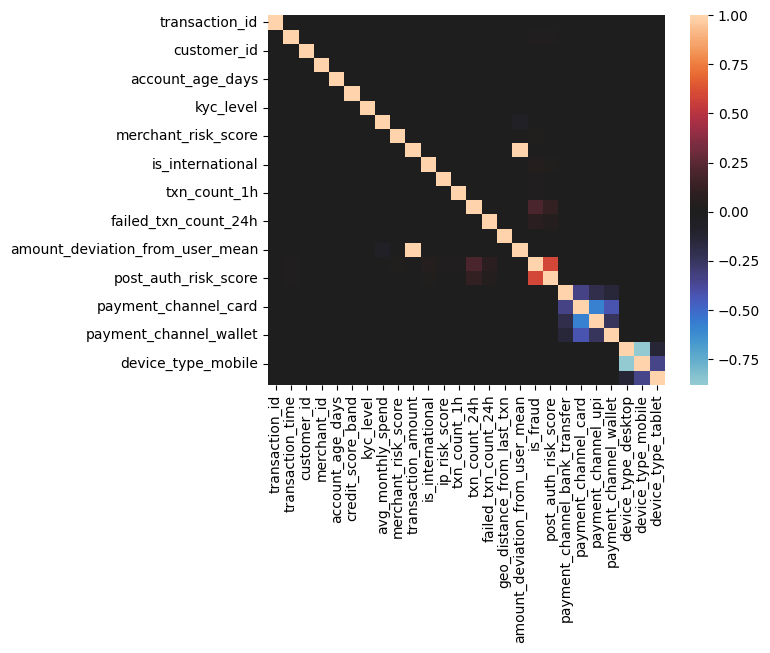

In [30]:
#блок с тепловой картой 

numeric_cols = df_transformed.select_dtypes(include=['int64', 'float64', 'bool']).columns.to_list()

print(numeric_cols)

sns.heatmap(df_transformed[numeric_cols].corr(), center=0)

In [31]:
#Блок с обучением модели

# Признаки (X) и целевая переменная (y)

X = df_transformed.drop(['is_fraud', 'post_auth_risk_score'], axis=1)
y = df_transformed['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6769
)

X_test.info()

<class 'pandas.DataFrame'>
Index: 60023 entries, 193522 to 231547
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   60023 non-null  int64  
 1   transaction_time                 60023 non-null  int64  
 2   customer_id                      60023 non-null  int64  
 3   merchant_id                      60023 non-null  int64  
 4   account_age_days                 60023 non-null  int64  
 5   credit_score_band                60023 non-null  int64  
 6   kyc_level                        60023 non-null  int64  
 7   avg_monthly_spend                60023 non-null  float64
 8   merchant_risk_score              60023 non-null  float64
 9   transaction_amount               60023 non-null  float64
 10  is_international                 60023 non-null  int64  
 11  ip_risk_score                    60023 non-null  float64
 12  txn_count_1h                

# Decision tree #

In [56]:
model = DecisionTreeClassifier(random_state=6769420)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",6769420
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [57]:
y_pred = model.predict(X_test)

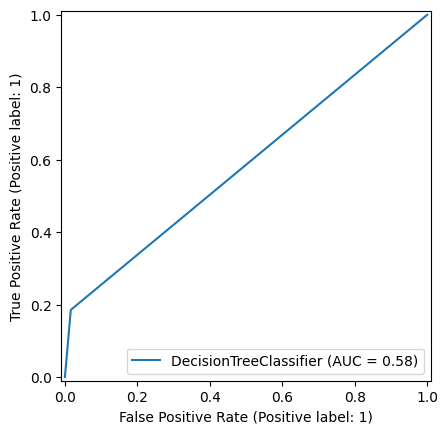

Accuracy: 0.9712276960498476
Precision: 0.9739927078634603
Recall: 0.9712276960498476
F1-score: 0.9725831126664957


In [58]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

# Random forest #

In [59]:
model_f = RandomForestClassifier(random_state=6769)
model_f.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [60]:
y_pred_f = model_f.predict(X_test)

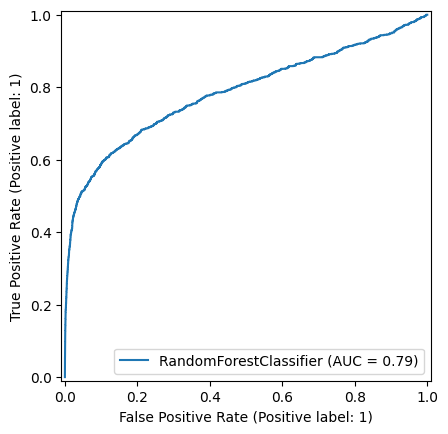

Accuracy: 0.9852223314396148
Precision: 0.9689895281407975
Recall: 0.9843726571480932
F1-score: 0.9766205199918576


In [55]:
RocCurveDisplay.from_estimator(model_f, X_test, y_test)
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred_f, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_f, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_f, average='weighted', zero_division=0))